Precomputing every (n0, n1) combination... this takes about 30 seconds.
Computing 40/1600 (n0=39, n1=0)...

/tmp/ipykernel_51893/903129189.py:37: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_val, _ = quad(integrand, 0, np.inf)


Computing 1520/1600 (n0=39, n1=37)...

/tmp/ipykernel_51893/903129189.py:98: RuntimeWarning: overflow encountered in exp
  w = rho * np.exp(-1j*delta) * constant_ratio * ratio_q * ratio_alpha * poly_ratio * np.exp(exp_arg)
/tmp/ipykernel_51893/903129189.py:98: RuntimeWarning: invalid value encountered in scalar multiply
  w = rho * np.exp(-1j*delta) * constant_ratio * ratio_q * ratio_alpha * poly_ratio * np.exp(exp_arg)
/tmp/ipykernel_51893/903129189.py:99: RuntimeWarning: invalid value encountered in scalar divide
  return [2.0 * np.imag((f0 + w*f1) / (1.0 + w))]


Computing 1600/1600 (n0=39, n1=39)...
Precomputation done!
Generating the 3D GIF...
-> Saved successfully: biverse_n1_evolution.gif


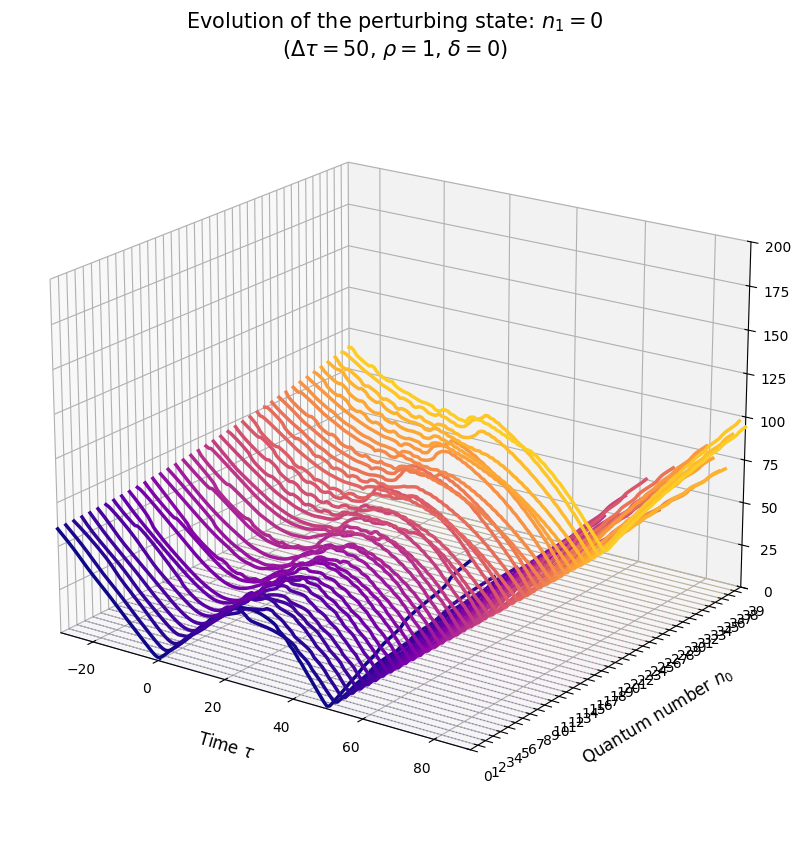

In [2]:
"""
3D Animation of Quantum Trajectories: Evolution with n1
Axes: X = tau (Time), Y = n0 (Quantum number), Z = x (Scale factor)
"""

import numpy as np
import math
import sys
from scipy.integrate import solve_ivp, quad
from scipy.special import gamma, genlaguerre
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.animation as animation

# ─────────────────────────────────────────────
# 1. FIXED GLOBAL PARAMETERS
# ─────────────────────────────────────────────
nu      = 1.0     # affine parameter
r       = 2.0     # energy ratio E1/E0
Dtau    = 50.0    # bounce-time separation
rho     = 1.0     # amplitude ratio
delta   = 0.0     # relative phase

E0, E1 = 1.0, r
tB0, tB1 = 0.0, Dtau

n0_values = np.arange(0, 40, 1)
n1_values = np.arange(0, 40, 1)

# ── Function to compute xi (ξ), the normalization/overlap constant of the
#    n-th affine coherent state ──
def compute_xi(n_val, nu_val):
    Ln_func = genlaguerre(n_val, nu_val)
    def integrand(y):
        return y**(nu_val + 0.5) * (Ln_func(y))**2 * np.exp(-y)
    integral_val, _ = quad(integrand, 0, np.inf)
    Gn = (math.factorial(n_val) / gamma(nu_val + n_val + 1)) * integral_val
    return Gn**2

def q_sc(t, qB, om, tB):
    return qB * np.sqrt(1.0 + om**2 * (t - tB)**2)

def p_sc(t, qB, om, tB):
    dt = t - tB
    return 0.5 * qB * om**2 * dt / np.sqrt(1.0 + om**2 * dt**2)

# ─────────────────────────────────────────────
# 2. TRAJECTORY INTEGRATION
# ─────────────────────────────────────────────
def compute_trajectory(n0_val, n1_val, tau_eval):
    # State parameters
    xi0, xi1 = compute_xi(n0_val, nu), compute_xi(n1_val, nu)
    qB0, qB1 = xi0 / np.sqrt(E0), xi1 / np.sqrt(E1)
    om0, om1 = 2 * E0 / xi0, 2 * E1 / xi1

    L_n0 = genlaguerre(n0_val, nu)
    L_n0_m1 = genlaguerre(n0_val - 1, nu + 1) if n0_val > 0 else lambda y: np.zeros_like(y)
    L_n1 = genlaguerre(n1_val, nu)
    L_n1_m1 = genlaguerre(n1_val - 1, nu + 1) if n1_val > 0 else lambda y: np.zeros_like(y)

    coeff_N0 = math.sqrt(math.factorial(n0_val) / gamma(nu + n0_val + 1))
    coeff_N1 = math.sqrt(math.factorial(n1_val) / gamma(nu + n1_val + 1))
    constant_ratio = (coeff_N1 / coeff_N0) * ((xi1 / xi0)**((nu + 1) / 2.0))

    def get_alpha_q(tau, qB, om, tB, xi_val):
        # alpha (α) is the complex Gaussian spread parameter of the wavefunction
        # branch: Re(α) = xi sets its width via q, Im(α) = -q*p carries the phase curvature
        q = q_sc(tau, qB, om, tB)
        p = p_sc(tau, qB, om, tB)
        return xi_val - 1j*q*p, q

    # Guidance equation right-hand side: Bohmian velocity field
    # dx/dtau = 2 Im[d(ln Psi)/dx] for the biverse superposition Psi = psi_0 + w*psi_1
    def guidance_rhs(tau, state):
        x = state[0]
        al0, q0 = get_alpha_q(tau, qB0, om0, tB0, xi0)
        al1, q1 = get_alpha_q(tau, qB1, om1, tB1, xi1)

        y0, y1 = xi0 * (x**2) / (q0**2), xi1 * (x**2) / (q1**2)
        eps = 1e-300  # avoids a 0/0 division right at the nodes of the Laguerre polynomials
        val_L0, val_L1 = L_n0(y0) + eps, L_n1(y1) + eps

        term_L0 = 2.0 * xi0 * (x / q0**2) * L_n0_m1(y0) / val_L0 if n0_val > 0 else 0.0
        term_L1 = 2.0 * xi1 * (x / q1**2) * L_n1_m1(y1) / val_L1 if n1_val > 0 else 0.0

        f0 = (nu + 0.5)/x - term_L0 - al0 * x / q0**2
        f1 = (nu + 0.5)/x - term_L1 - al1 * x / q1**2

        power_phase0, power_phase1 = (2*n0_val + nu + 1)/2.0, (2*n1_val + nu + 1)/2.0

        ratio_q = (q0/q1)**(nu + 1)
        ratio_alpha = (al1 / np.conj(al1))**power_phase1 / (al0 / np.conj(al0))**power_phase0
        poly_ratio = val_L1 / val_L0
        exp_arg = 0.5 * x**2 * (al0/q0**2 - al1/q1**2)

        # w = psi_1/psi_0, weighted by the biverse amplitude ratio rho and phase delta
        w = rho * np.exp(-1j*delta) * constant_ratio * ratio_q * ratio_alpha * poly_ratio * np.exp(exp_arg)
        return [2.0 * np.imag((f0 + w*f1) / (1.0 + w))]

    x_i = q_sc(tau_eval[0], qB0, om0, tB0)
    sol = solve_ivp(
        guidance_rhs, (tau_eval[0], tau_eval[-1]), [x_i],
        method='RK45', t_eval=tau_eval,
        rtol=1e-7, atol=1e-9
    )
    return sol.t, sol.y[0]

# ─────────────────────────────────────────────
# 3. PRECOMPUTE ALL TRAJECTORIES
# ─────────────────────────────────────────────
tau_array = np.linspace(-30.0, 90.0, 1500)
trajectories = {}

print("Precomputing every (n0, n1) combination... this takes about 30 seconds.")
total_calcs = len(n0_values) * len(n1_values)
calc_count = 0

for n1_val in n1_values:
    for n0_val in n0_values:
        calc_count += 1
        sys.stdout.write(f"\rComputing {calc_count}/{total_calcs} (n0={n0_val}, n1={n1_val})...")
        sys.stdout.flush()
        t_res, x_res = compute_trajectory(n0_val, n1_val, tau_array)
        trajectories[(n0_val, n1_val)] = (t_res, x_res)
print("\nPrecomputation done!")

# ─────────────────────────────────────────────
# 4. 3D ANIMATION SETUP
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = cm.plasma(np.linspace(0, 0.9, len(n0_values)))

# Initialize the 3D line artists
lines = []
shadows = []
for i in range(len(n0_values)):
    # Main trajectory lines
    line, = ax.plot([], [], [], linewidth=2.5, color=colors[i])
    lines.append(line)
    # Shadows (to make the 3D depth easier to read)
    shadow, = ax.plot([], [], [], color=colors[i], alpha=0.3, linewidth=1, linestyle=':')
    shadows.append(shadow)

# Fixed axis configuration
ax.set_xlabel("Time $\\tau$", fontsize=12, labelpad=10)
ax.set_ylabel("Quantum number $n_0$", fontsize=12, labelpad=10)
ax.set_zlabel("Scale factor $x$", fontsize=12, labelpad=10)

ax.set_xlim(-30, 90)
ax.set_ylim(0, 5)
ax.set_zlim(0, 200)  # fixed z-limit so the frame doesn't rescale (tuned empirically)

ax.set_yticks(n0_values)
title_text = ax.set_title("", fontsize=15)

# Camera stays strictly fixed across frames!
ax.view_init(elev=20, azim=-55)

# ─────────────────────────────────────────────
# 5. UPDATE FUNCTION AND GENERATION
# ─────────────────────────────────────────────
def update(frame):
    n1_current = n1_values[frame]

    # Update the title
    title_text.set_text(f"Evolution of the perturbing state: $n_1 = {n1_current}$"
                        f"\n($\\Delta\\tau = 50$, $\\rho = 1$, $\\delta = 0$)")

    for i, n0_current in enumerate(n0_values):
        t_res, x_res = trajectories[(n0_current, n1_current)]
        n0_arr = np.full_like(t_res, n0_current)

        # Matplotlib 3D trick: set (X, Y) first, then Z
        lines[i].set_data(t_res, n0_arr)
        lines[i].set_3d_properties(x_res)

        # Shadow projected onto the Z=0 plane
        shadows[i].set_data(t_res, n0_arr)
        shadows[i].set_3d_properties(np.zeros_like(x_res))

    return lines + shadows + [title_text]

print("Generating the 3D GIF...")
# fps=1.5-ish gives a smooth "slideshow" effect between successive integer states
ani = animation.FuncAnimation(fig, update, frames=len(n1_values), blit=False)
gif_name = "biverse_n1_evolution.gif"
ani.save(gif_name, writer='pillow', fps=4.0)

print(f"-> Saved successfully: {gif_name}")
